In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"D:\python for data science\pandas_demo\sample dataset\job_data_merged_1.csv")

In [3]:
df

,Unnamed: 0,Category,Workplace,Location,Department,Type
0,0,Business Analyst,Remote,United Kingdom,Operations,Full time
1,1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time
2,2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time
3,3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time
4,4,Business Analyst,Remote,United Kingdom,Operations,Full time
...,...,...,...,...,...,...
1090,1090,UI/UX,Remote,"Paris, Île-de-France, France",Content,Other
1091,1091,UI/UX,Remote,"Athens, Attica, Greece",Engineering,Full time
1092,1092,UI/UX,On-site,"Bulverde, Texas, United States",Marketing,Full time
1093,1093,UI/UX,On-site,"Amsterdam, North Holland, Netherlands","Marketing, Communications and Events",Full time


In [4]:
df = df.drop(columns= ["Unnamed: 0"])

In [5]:
#removing duplicates using .drop_duplicates()

In [6]:
df = df.drop_duplicates()

In [7]:
df

,Category,Workplace,Location,Department,Type
0,Business Analyst,Remote,United Kingdom,Operations,Full time
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,NaN
...,...,...,...,...,...
1090,UI/UX,Remote,"Paris, Île-de-France, France",Content,Other
1091,UI/UX,Remote,"Athens, Attica, Greece",Engineering,Full time
1092,UI/UX,On-site,"Bulverde, Texas, United States",Marketing,Full time
1093,UI/UX,On-site,"Amsterdam, North Holland, Netherlands","Marketing, Communications and Events",Full time


In [8]:
df["Workplace"] = df["Workplace"].replace({"Sur cite" : "On-site", "Hybride":"Hybrid", "On-Site" : "On-site" })
df["Type"] = df["Type"].replace({"Temps plein" : "Full Time"})

In [9]:
df


,Category,Workplace,Location,Department,Type
0,Business Analyst,Remote,United Kingdom,Operations,Full time
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full time
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full time
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full time
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,NaN
...,...,...,...,...,...
1090,UI/UX,Remote,"Paris, Île-de-France, France",Content,Other
1091,UI/UX,Remote,"Athens, Attica, Greece",Engineering,Full time
1092,UI/UX,On-site,"Bulverde, Texas, United States",Marketing,Full time
1093,UI/UX,On-site,"Amsterdam, North Holland, Netherlands","Marketing, Communications and Events",Full time


In [10]:
df["Workplace"].unique()

<StringArray>
['Remote', 'On-site', 'Hybrid', nan]
Length: 4, dtype: str

In [11]:
df["Type"].unique()

<StringArray>
['Full time', nan, 'Contract', 'Other', 'Part time', 'Temporary', 'Full Time']
Length: 7, dtype: str

In [12]:
df["Type"] = df["Type"].replace({"Full time" : "Full Time"})

In [13]:
df["Type"].unique()

<StringArray>
['Full Time', nan, 'Contract', 'Other', 'Part time', 'Temporary']
Length: 6, dtype: str

In [14]:
#removing nul valaues or filling it with relevaant data using .fillna()

In [15]:
df = df.fillna("Not Specified")

In [16]:
df["Type"].unique()

<StringArray>
['Full Time', 'Not Specified', 'Contract', 'Other', 'Part time', 'Temporary']
Length: 6, dtype: str

In [17]:
df[df.duplicated() == False]

,Category,Workplace,Location,Department,Type
0,Business Analyst,Remote,United Kingdom,Operations,Full Time
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full Time
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full Time
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full Time
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified
...,...,...,...,...,...
1090,UI/UX,Remote,"Paris, Île-de-France, France",Content,Other
1091,UI/UX,Remote,"Athens, Attica, Greece",Engineering,Full Time
1092,UI/UX,On-site,"Bulverde, Texas, United States",Marketing,Full Time
1093,UI/UX,On-site,"Amsterdam, North Holland, Netherlands","Marketing, Communications and Events",Full Time


In [18]:
df.to_csv(r"D:\python for data science\pandas_demo\sample dataset\job_data_cleaned.csv", index=False)

In [19]:
df

,Category,Workplace,Location,Department,Type
0,Business Analyst,Remote,United Kingdom,Operations,Full Time
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full Time
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full Time
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full Time
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified
...,...,...,...,...,...
1090,UI/UX,Remote,"Paris, Île-de-France, France",Content,Other
1091,UI/UX,Remote,"Athens, Attica, Greece",Engineering,Full Time
1092,UI/UX,On-site,"Bulverde, Texas, United States",Marketing,Full Time
1093,UI/UX,On-site,"Amsterdam, North Holland, Netherlands","Marketing, Communications and Events",Full Time


In [20]:
df["Category"].unique()

<StringArray>
[  'Business Analyst',              'Cloud',     'Data Scientist',
                 'HR', 'Software Developer',              'UI/UX']
Length: 6, dtype: str

In [21]:
#Split `Location` into City, Region, Country:

In [22]:
def split_location(loc):
    if pd.isna(loc):
        return pd.Series([None,None,None])
    parts = [p.strip() for p in loc.split(",")]
    if len(parts) == 3:
        return pd.Series(parts)           #city, region , country
    elif len(parts) == 1:
        return pd.Series([None, None, parts[0]])
    else:
        return pd.Series([parts[0], None, parts[-1]])
df[["City", "Region", "Country"]] = df["Location"].apply(split_location)

In [23]:
df

,Category,Workplace,Location,Department,Type,City,Region,Country
0,Business Analyst,Remote,United Kingdom,Operations,Full Time,NaN,NaN,United Kingdom
1,Business Analyst,Remote,"Makati, Metro Manila, Philippines",Aux HQ,Full Time,Makati,Metro Manila,Philippines
2,Business Analyst,On-site,"Al-Dajeej, Al Farwaniyah Governorate, Kuwait",PWC Technologies,Full Time,Al-Dajeej,Al Farwaniyah Governorate,Kuwait
3,Business Analyst,On-site,"London, England, United Kingdom","Consultants, Advisory",Full Time,London,England,United Kingdom
8,Business Analyst,Remote,"London, England, United Kingdom",Change & Innovation,Not Specified,London,England,United Kingdom
...,...,...,...,...,...,...,...,...
1090,UI/UX,Remote,"Paris, Île-de-France, France",Content,Other,Paris,Île-de-France,France
1091,UI/UX,Remote,"Athens, Attica, Greece",Engineering,Full Time,Athens,Attica,Greece
1092,UI/UX,On-site,"Bulverde, Texas, United States",Marketing,Full Time,Bulverde,Texas,United States
1093,UI/UX,On-site,"Amsterdam, North Holland, Netherlands","Marketing, Communications and Events",Full Time,Amsterdam,North Holland,Netherlands


In [24]:
category_counts = df["Category"].value_counts()

In [25]:
workplace_by_category = pd.crosstab(df["Category"], df["Workplace"])
print(workplace_by_category.round(1))

Workplace           Hybrid  Not Specified  On-site  Remote
Category                                                  
Business Analyst        24              3       56      25
Cloud                   24              6       38      52
Data Scientist          16              3       63      53
HR                      15              4       63      30
Software Developer      15              6       44      41
UI/UX                   10              2       31      48


In [26]:
#percentage of category in each work place

In [27]:
workplace_by_category = pd.crosstab(df["Category"], df["Workplace"], normalize= "index")*100 
print(workplace_by_category.round(1))

Workplace           Hybrid  Not Specified  On-site  Remote
Category                                                  
Business Analyst      22.2            2.8     51.9    23.1
Cloud                 20.0            5.0     31.7    43.3
Data Scientist        11.9            2.2     46.7    39.3
HR                    13.4            3.6     56.2    26.8
Software Developer    14.2            5.7     41.5    38.7
UI/UX                 11.0            2.2     34.1    52.7


In [28]:
#top hiring location

In [29]:
top_countries = df["Country"].value_counts().head(10)
print(top_countries)

Country
United States     166
United Kingdom    102
India              51
Not Specified      28
Philippines        26
Greece             23
Canada             22
Australia          17
France             14
Nigeria            14
Name: count, dtype: int64


In [30]:
# Or drill into top cities specifically 
top_cities = df['City'].value_counts().head(10) 
print(top_cities)

City
London       53
New York     19
Athens       16
Bengaluru    16
Cairo        12
Dubai        11
Gurugram     11
Lagos        10
Riyadh       10
Paris         9
Name: count, dtype: int64


In [31]:
top_country_by_category = df.groupby('Category')['Country'].agg(lambda x: x.value_counts().index[0])
print(top_country_by_category)

Category
Business Analyst      United States
Cloud                 United States
Data Scientist        United States
HR                    United States
Software Developer    United States
UI/UX                 United States
Name: Country, dtype: str


In [32]:
#Analyze department and employment type

In [33]:
#top departments
top_departments = df["Department"].value_counts().head()
print(top_departments)

Department
Not Specified    97
Engineering      51
Product          21
Technology       17
Sales            16
Name: count, dtype: int64


In [34]:
type_by_category = pd.crosstab(df["Category"], df["Type"], normalize="index")*100
print(type_by_category.round(1))

Type                Contract  Full Time  Not Specified  Other  Part time  \
Category                                                                   
Business Analyst         8.3       73.1           16.7    0.9        0.9   
Cloud                    3.3       79.2           15.8    1.7        0.0   
Data Scientist           0.7       83.0           12.6    0.7        0.7   
HR                       4.5       75.0           14.3    0.9        4.5   
Software Developer       2.8       77.4           13.2    3.8        0.0   
UI/UX                    3.3       80.2           13.2    2.2        0.0   

Type                Temporary  
Category                       
Business Analyst          0.0  
Cloud                     0.0  
Data Scientist            2.2  
HR                        0.9  
Software Developer        2.8  
UI/UX                     1.1  


Visualize with Matplotlib/



In [35]:
#Visualize with Matplotlib

In [36]:
import matplotlib.pyplot as plt

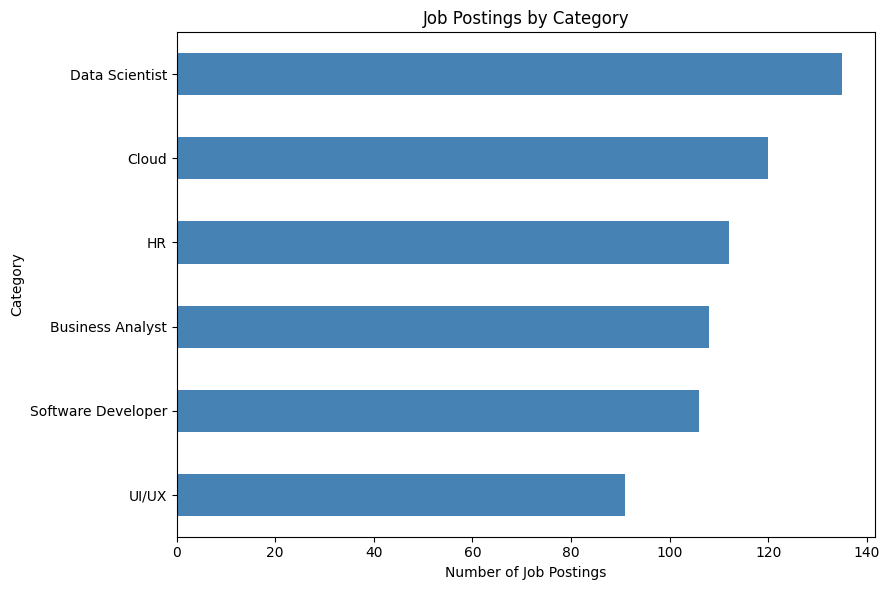

In [37]:

plt.figure(figsize=(9,6))
category_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Job Postings')
plt.title('Job Postings by Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('category_distribution.png')
plt.show()

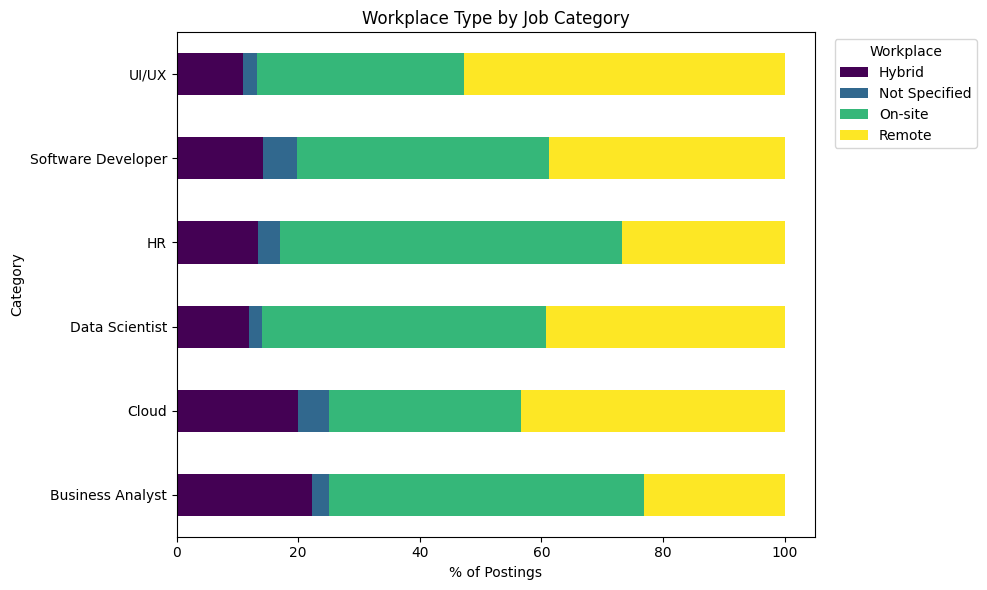

In [38]:
plt.figure(figsize=(10,6))
workplace_by_category.plot(kind='barh', stacked=True, colormap='viridis', ax=plt.gca())
plt.xlabel('% of Postings') 
plt.title('Workplace Type by Job Category') 
plt.legend(title='Workplace', bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.savefig('workplace_by_category.png') 
plt.show()

a word cloud of hiring locations

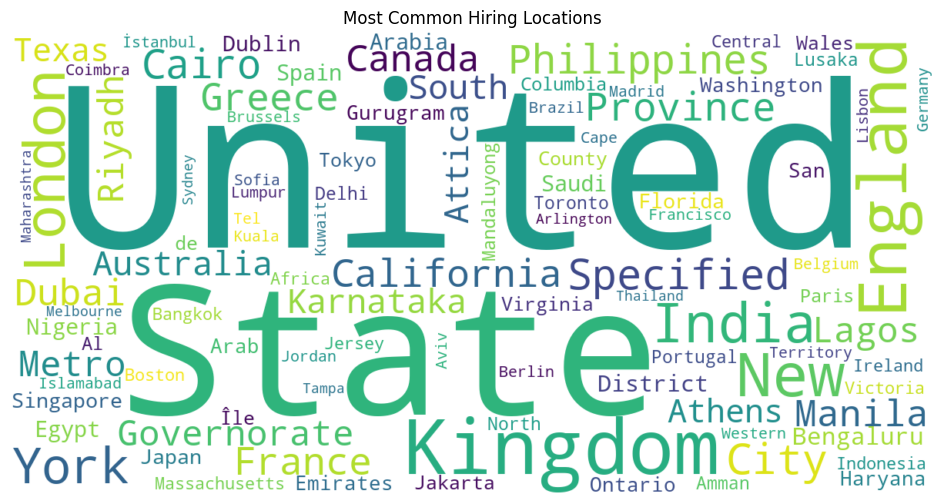

In [39]:
from wordcloud import WordCloud 
location_text = ' '.join(df['Location'].dropna()) 
wordcloud = WordCloud(width=1200, height=600, background_color='white', max_words=100, collocations=False).generate(location_text) 
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 
plt.title('Most Common Hiring Locations') 
plt.savefig('location_wordcloud.png') 
plt.show()

In [40]:
!pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
